# Visualización de máscaras I-JEPA sobre imágenes GADF

Muestra qué patches de una imagen GADF se asignan a **contexto** (el encoder los ve)
y cuáles son **targets** (el predictor debe reconstruirlos).

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

from src.masks.multiblock import MaskCollator

In [2]:
# ── Parámetros (deben coincidir con gadf_soil_nir.yaml) ──────────────────────
PATCH_SIZE = 16
CROP_SIZE  = 224
H = W      = CROP_SIZE // PATCH_SIZE   # 14×14 = 196 patches
NENC       = 1
NPRED      = 4
H5_PATH    = "../data/gadf_224.h5"

# Colores para los 4 bloques target
TARGET_COLORS = ["#e74c3c", "#e67e22", "#8e44ad", "#16a085"]
TARGET_LABELS = [f"Target {i+1}" for i in range(NPRED)]

In [3]:
# ── Cargar una imagen real del HDF5 ──────────────────────────────────────────
with h5py.File(H5_PATH, "r") as f:
    img_np = f["images"][0].astype(np.float32)   # (1, 224, 224)

img_2d = img_np[0]   # (224, 224)
print(f"Imagen cargada: shape={img_np.shape}  min={img_2d.min():.3f}  max={img_2d.max():.3f}")

Imagen cargada: shape=(1, 224, 224)  min=-1.000  max=1.000


In [4]:
# ── Generar máscaras con el mismo collator que en entrenamiento ───────────────
collator = MaskCollator(
    input_size=(CROP_SIZE, CROP_SIZE),
    patch_size=PATCH_SIZE,
    pred_mask_scale=(0.15, 0.2),
    enc_mask_scale=(0.85, 1.0),
    aspect_ratio=(0.75, 1.5),
    nenc=NENC,
    npred=NPRED,
    min_keep=10,
    allow_overlap=False,
    symmetric_masking=True,
)

# El collator espera una lista de (tensor, label)
img_tensor = torch.from_numpy(img_np)
batch = [(img_tensor, 0)]
_, masks_enc, masks_pred = collator(batch)

# Extraer índices para la imagen 0
enc_indices  = masks_enc[0][0].tolist()          # lista de ints
pred_indices = [masks_pred[p][0].tolist() for p in range(NPRED)]

print(f"Patches contexto (encoder): {len(enc_indices)}/{H*W}  ({100*len(enc_indices)/(H*W):.1f}%)")
for i, pi in enumerate(pred_indices):
    print(f"Patches target {i+1}:          {len(pi)}/{H*W}  ({100*len(pi)/(H*W):.1f}%)")

Patches contexto (encoder): 27/196  (13.8%)
Patches target 1:          36/196  (18.4%)
Patches target 2:          36/196  (18.4%)
Patches target 3:          36/196  (18.4%)
Patches target 4:          36/196  (18.4%)


In [5]:
# ── Construir mapa de roles por patch ─────────────────────────────────────────
# 0 = invisible (ni contexto ni target)
# 1 = contexto
# 2..5 = target 1..4
role_map = np.zeros((H, W), dtype=int)

for idx in enc_indices:
    row, col = divmod(idx, W)
    role_map[row, col] = 1

for p, indices in enumerate(pred_indices):
    for idx in indices:
        row, col = divmod(idx, W)
        role_map[row, col] = p + 2   # 2,3,4,5

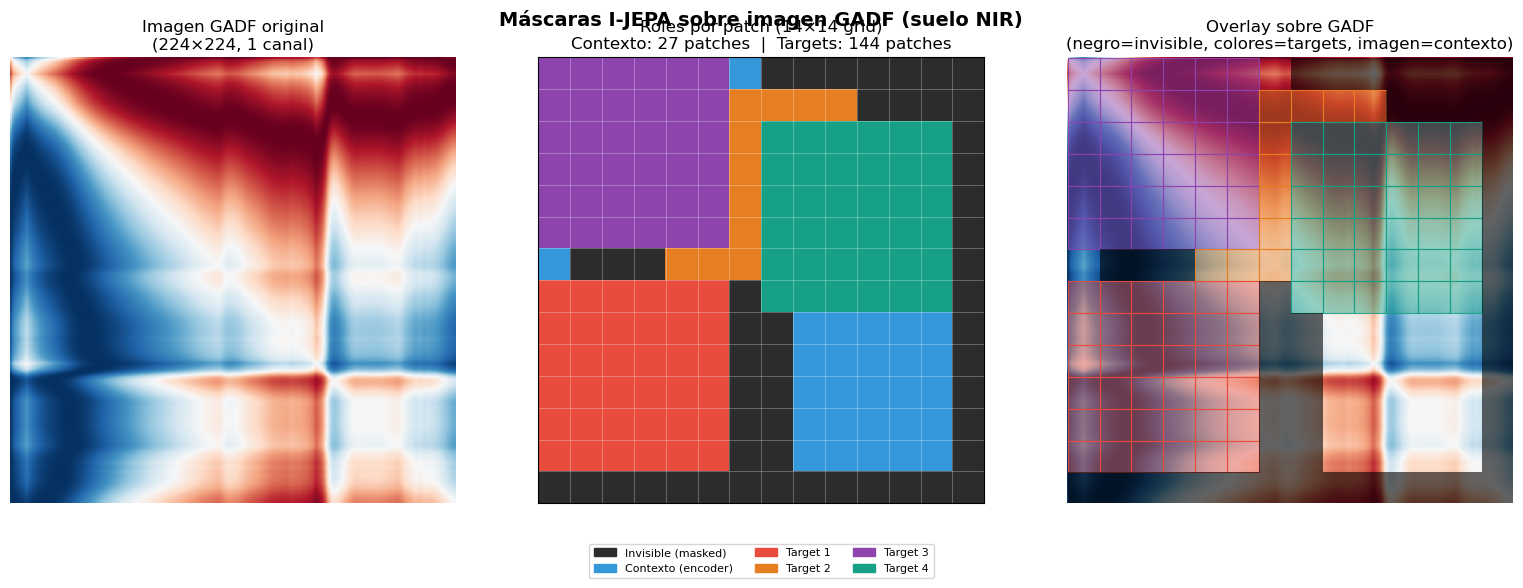

Guardado en gadf_masks_visualization.png


In [6]:
# ── Figura principal ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle("Máscaras I-JEPA sobre imagen GADF (suelo NIR)", fontsize=14, fontweight="bold")

# --- Panel 1: imagen GADF original ---
ax = axes[0]
ax.imshow(img_2d, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_title("Imagen GADF original\n(224×224, 1 canal)")
ax.axis("off")

# --- Panel 2: mapa de roles (patch grid) ---
ax = axes[1]
# Colormap: gris oscuro=invisible, azul=contexto, colores=targets
cmap_colors = ["#2c2c2c", "#3498db"] + TARGET_COLORS
cmap = ListedColormap(cmap_colors)
ax.imshow(role_map, cmap=cmap, vmin=0, vmax=5, interpolation="nearest")

# Grid de patches
for i in range(H + 1):
    ax.axhline(i - 0.5, color="white", linewidth=0.4, alpha=0.5)
for j in range(W + 1):
    ax.axvline(j - 0.5, color="white", linewidth=0.4, alpha=0.5)

ax.set_title(f"Roles por patch (14×14 grid)\n"
             f"Contexto: {len(enc_indices)} patches  |  "
             f"Targets: {sum(len(p) for p in pred_indices)} patches")
ax.set_xticks([]); ax.set_yticks([])

legend_handles = [
    mpatches.Patch(color="#2c2c2c", label="Invisible (masked)"),
    mpatches.Patch(color="#3498db", label="Contexto (encoder)"),
] + [
    mpatches.Patch(color=TARGET_COLORS[i], label=TARGET_LABELS[i])
    for i in range(NPRED)
]
ax.legend(handles=legend_handles, loc="lower center",
          bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=8)

# --- Panel 3: overlay sobre la imagen GADF ---
ax = axes[2]
ax.imshow(img_2d, cmap="RdBu_r", vmin=-1, vmax=1)

# Dibujar rectángulos coloreados por rol con transparencia
alpha_map = {0: 0.65, 1: 0.0}   # invisible=opaco oscuro, contexto=transparente
for row in range(H):
    for col in range(W):
        role = role_map[row, col]
        x = col * PATCH_SIZE
        y = row * PATCH_SIZE
        if role == 0:
            rect = plt.Rectangle((x, y), PATCH_SIZE, PATCH_SIZE,
                                  facecolor="black", alpha=0.6, linewidth=0)
            ax.add_patch(rect)
        elif role >= 2:
            color = TARGET_COLORS[role - 2]
            rect = plt.Rectangle((x, y), PATCH_SIZE, PATCH_SIZE,
                                  facecolor=color, alpha=0.45, linewidth=0)
            ax.add_patch(rect)
            # Borde del bloque target
            rect_border = plt.Rectangle((x, y), PATCH_SIZE, PATCH_SIZE,
                                        facecolor="none", edgecolor=color,
                                        linewidth=0.8, alpha=0.9)
            ax.add_patch(rect_border)

ax.set_title("Overlay sobre GADF\n(negro=invisible, colores=targets, imagen=contexto)")
ax.axis("off")

plt.tight_layout()
plt.savefig("../gadf_masks_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado en gadf_masks_visualization.png")

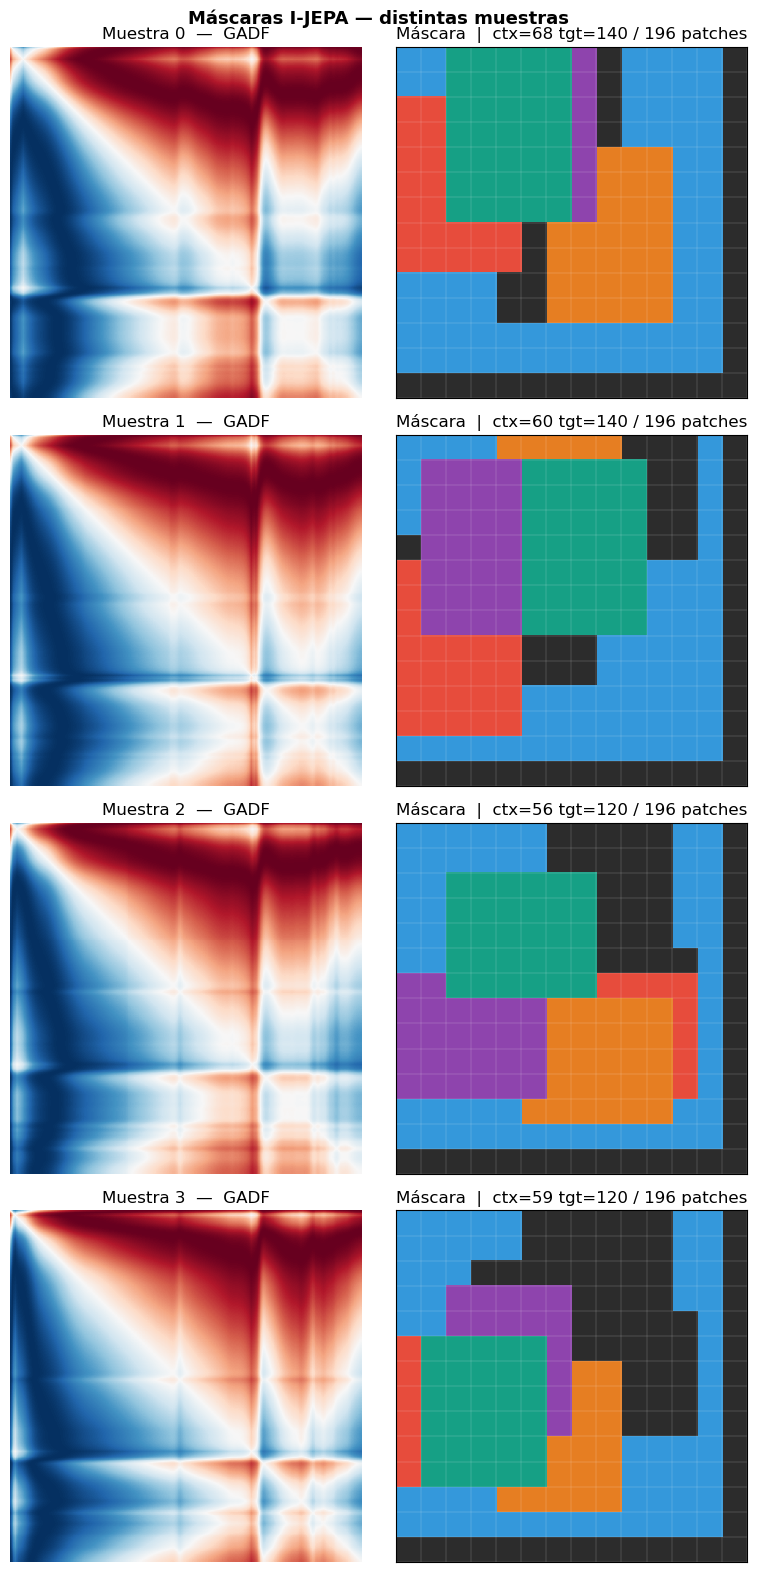

In [7]:
# ── Bonus: visualizar varias muestras con distintas máscaras ─────────────────
N_SAMPLES = 4

with h5py.File(H5_PATH, "r") as f:
    imgs_np = f["images"][:N_SAMPLES].astype(np.float32)  # (N, 1, 224, 224)

fig, axes = plt.subplots(N_SAMPLES, 2, figsize=(8, 4 * N_SAMPLES))
fig.suptitle("Máscaras I-JEPA — distintas muestras", fontsize=13, fontweight="bold")

for i in range(N_SAMPLES):
    batch_i = [(torch.from_numpy(imgs_np[i]), 0)]
    _, masks_enc_i, masks_pred_i = collator(batch_i)

    enc_idx_i  = masks_enc_i[0][0].tolist()
    pred_idx_i = [masks_pred_i[p][0].tolist() for p in range(NPRED)]

    role_i = np.zeros((H, W), dtype=int)
    for idx in enc_idx_i:
        role_i[divmod(idx, W)] = 1
    for p, pidx in enumerate(pred_idx_i):
        for idx in pidx:
            role_i[divmod(idx, W)] = p + 2

    # imagen
    axes[i, 0].imshow(imgs_np[i, 0], cmap="RdBu_r", vmin=-1, vmax=1)
    axes[i, 0].set_title(f"Muestra {i}  —  GADF"); axes[i, 0].axis("off")

    # mapa roles
    axes[i, 1].imshow(role_i, cmap=cmap, vmin=0, vmax=5, interpolation="nearest")
    for k in range(H + 1):
        axes[i, 1].axhline(k - 0.5, color="white", linewidth=0.3, alpha=0.4)
    for k in range(W + 1):
        axes[i, 1].axvline(k - 0.5, color="white", linewidth=0.3, alpha=0.4)
    axes[i, 1].set_title(f"Máscara  |  ctx={len(enc_idx_i)} tgt={sum(len(p) for p in pred_idx_i)}"
                         f" / {H*W} patches")
    axes[i, 1].set_xticks([]); axes[i, 1].set_yticks([])

plt.tight_layout()
plt.show()